# EcoSort Waste Management Assistant
# Module 8 Summative Lab

## Overview

You are a data scientist at "EcoSort," a technology company that specializes in developing AI solutions for waste management. EcoSort has partnered with Metro City's waste management department to develop an intelligent waste management assistant that can help residents properly dispose of waste items so less time is spent sorting material at facilities.

This assistant needs to:

1. Identify waste materials from images uploaded by residents (CNN)
2. Classify waste items based on text descriptions provided by residents (RNN/Transformer)
3. Generate specific recycling instructions based on identified waste type and city policies (Generative Transformer with RAG)

Your task is to build this integrated system using the RealWaste dataset along with generated text data that simulates real-world waste management operations.

## Part 1: Dataset Exploration and Preparation

In this section, you will explore and prepare the datasets for your models.

### 1.1 Load and Explore the RealWaste Dataset

In [1]:
# Import necessary libraries
import os, random, pathlib, json, re, string
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
from PIL import Image
import warnings
warnings.filterwarnings('ignore')

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

# Set random seeds for reproducibility
np.random.seed(42)
tf.random.set_seed(42)
random.seed(42)

Number of classes: 9
Class names: ['Cardboard', 'Food Organics', 'Glass', 'Metal', 'Miscellaneous Trash', 'Paper', 'Plastic', 'Textile Trash', 'Vegetation']
Image counts per class: {'Cardboard': 461, 'Food Organics': 411, 'Glass': 420, 'Metal': 790, 'Miscellaneous Trash': 495, 'Paper': 500, 'Plastic': 921, 'Textile Trash': 318, 'Vegetation': 436}


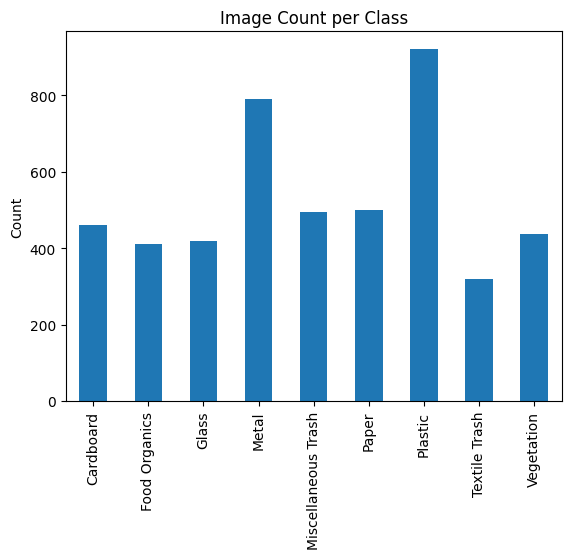

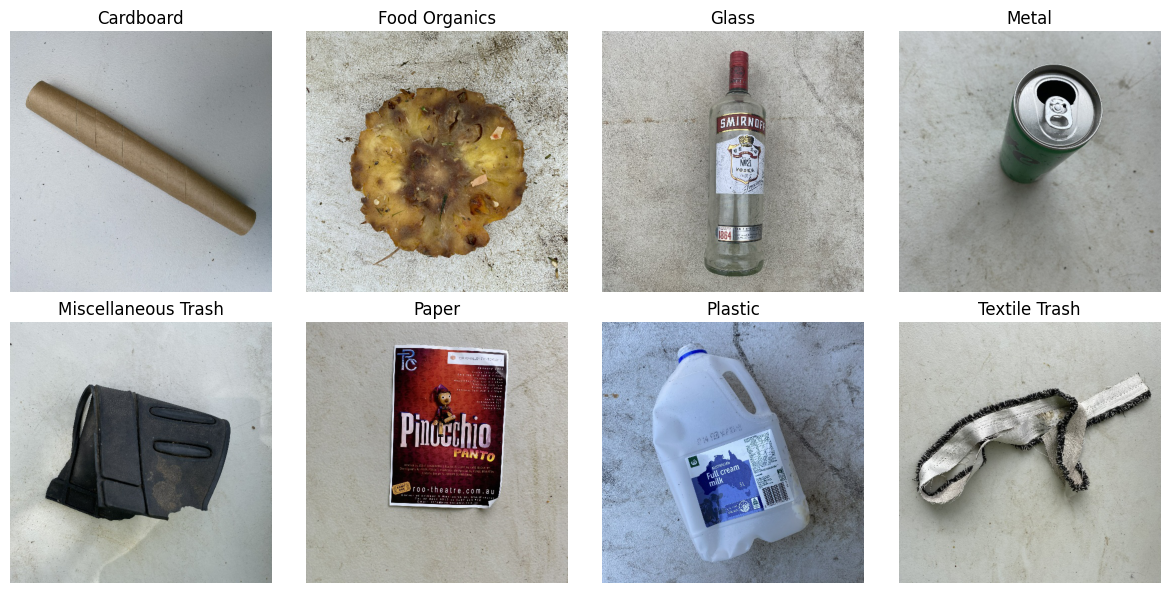

       width  height
count  180.0   180.0
mean   524.0   524.0
std      0.0     0.0
min    524.0   524.0
25%    524.0   524.0
50%    524.0   524.0
75%    524.0   524.0
max    524.0   524.0


In [4]:
# Load and explore the RealWaste dataset
data_dir = pathlib.Path('RealWaste/realwaste-main/RealWaste')


# Class names and counts
class_names = sorted([item.name for item in data_dir.glob('*') if item.is_dir()])
num_classes = len(class_names)
print(f"Number of classes: {num_classes}")
print(f"Class names: {class_names}")

image_counts = {}
for cls in class_names:
    image_counts[cls] = len(list((data_dir / cls).glob('*.jpg'))) + \
                        len(list((data_dir / cls).glob('*.png')))
print("Image counts per class:", image_counts)

# Plot distribution
pd.Series(image_counts).plot(kind='bar', title='Image Count per Class')
plt.ylabel('Count')
plt.show()

# Sample images
plt.figure(figsize=(12, 6))
for i, cls in enumerate(class_names[:8]):
    img_path = list((data_dir / cls).glob('*'))[0]
    img = Image.open(img_path)
    plt.subplot(2, 4, i + 1)
    plt.imshow(img)
    plt.title(cls)
    plt.axis('off')
plt.tight_layout()
plt.show()

# Image size analysis
sizes = []
for cls in class_names:
    for img_path in list((data_dir / cls).glob('*'))[:20]:
        img = Image.open(img_path)
        sizes.append(img.size)
size_df = pd.DataFrame(sizes, columns=['width', 'height'])
print(size_df.describe())

### 1.2 Explore Text Datasets

In [5]:
# Load and explore the waste description text data
desc_df = pd.read_csv('waste_descriptions.csv')
print(desc_df.head())
print("Columns:", desc_df.columns.tolist())
print(desc_df['category'].value_counts())

# Description length
desc_df['desc_len'] = desc_df['description'].astype(str).str.split().str.len()
print(desc_df['desc_len'].describe())

# Vocabulary
all_words = ' '.join(desc_df['description'].astype(str)).lower().split()
vocab = Counter(all_words)
print("Most common words:", vocab.most_common(20))

                                         description       category  \
0                           soiled silver tablecloth  Textile Trash   
1                        folded glass bottle leaking          Glass   
2  large Supermarket vegetable waste with food re...  Food Organics   
3                         intact floral carpet piece  Textile Trash   
4                  empty fun-sized purple apple core  Food Organics   

                                disposal_instruction  \
0  Look for textile recycling programs in your area.   
1     Remove caps, lids, and corks before recycling.   
2   If no compost available, place in general waste.   
3  Look for textile recycling programs in your area.   
4           Keep separate from recyclable materials.   

                                    common_confusion  \
0                                                NaN   
1                                                NaN   
2                                                NaN   
3           

In [6]:
# Load and explore the waste policy documents
try:
    policy_df = pd.read_csv('waste_policy_documents.csv')
except FileNotFoundError:
    with open('waste_policy_documents.json', 'r') as f:
        policy_data = json.load(f)
    policy_df = pd.DataFrame(policy_data)

print(policy_df.head())
print("Policy columns:", policy_df.columns.tolist())

   policy_id                         policy_type categories_covered  \
0          1  Textile Trash Recycling Guidelines    [Textile Trash]   
1          2          Glass Recycling Guidelines            [Glass]   
2          3  Food Organics Recycling Guidelines    [Food Organics]   
3          4        Plastic Recycling Guidelines          [Plastic]   
4          5     Vegetation Recycling Guidelines       [Vegetation]   

  effective_date                                      document_text  \
0     2023-11-04  TEXTILE RECYCLING GUIDELINES\n\nAcceptable Ite...   
1     2023-01-24  GLASS RECYCLING GUIDELINES\n\nAcceptable Items...   
2     2023-05-08  FOOD ORGANICS RECYCLING GUIDELINES\n\nAcceptab...   
3     2023-04-05  PLASTIC RECYCLING GUIDELINES\n\nAcceptable Ite...   
4     2023-12-04  VEGETATION RECYCLING GUIDELINES\n\nAcceptable ...   

  jurisdiction  
0   Metro City  
1   Metro City  
2   Metro City  
3   Metro City  
4   Metro City  
Policy columns: ['policy_id', 'policy_type',

### 1.3 Create Data Pipelines

In [7]:
# Run this code to setup the images properly into train, validation, and test sets
# Set your data directory path - update this with your actual path
import pathlib
data_dir = pathlib.Path('RealWaste')

# Parameters
BATCH_SIZE = 32
IMG_HEIGHT = 224
IMG_WIDTH = 224

# Calculate the total number of classes automatically from the directory structure
num_classes = len([item for item in data_dir.glob('*') if item.is_dir()])
print(f"Number of classes: {num_classes}")

# List all class folders
class_names = sorted([item.name for item in data_dir.glob('*') if item.is_dir()])
print(f"Class names: {class_names}")

# Count all images
image_count = len(list(data_dir.glob('*/*.jpg'))) + len(list(data_dir.glob('*/*.png')))
print(f"Total images found: {image_count}")

# Create a dataset using tf.keras.utils.image_dataset_from_directory
# This will automatically split the data into training and validation sets
train_ds = tf.keras.utils.image_dataset_from_directory(
    data_dir,
    validation_split=0.2,  # 20% for validation
    subset="training",
    seed=42,
    image_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    label_mode='categorical',  # For one-hot encoded labels
    shuffle=True
)

validation_ds = tf.keras.utils.image_dataset_from_directory(
    data_dir,
    validation_split=0.2,  # 20% for validation
    subset="validation",
    seed=42,
    image_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    label_mode='categorical',  # For one-hot encoded labels
    shuffle=True
)

# Create a separate test dataset by taking part of the validation set
# First, let's get the number of batches in the validation set
val_batches = tf.data.experimental.cardinality(validation_ds)
test_dataset = validation_ds.take(val_batches // 2)
validation_ds = validation_ds.skip(val_batches // 2)

print(f"Number of training batches: {tf.data.experimental.cardinality(train_ds)}")
print(f"Number of validation batches: {tf.data.experimental.cardinality(validation_ds)}")
print(f"Number of test batches: {tf.data.experimental.cardinality(test_dataset)}")

# Configure dataset for performance
AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.cache().prefetch(buffer_size=AUTOTUNE)
validation_ds = validation_ds.cache().prefetch(buffer_size=AUTOTUNE)
test_dataset = test_dataset.cache().prefetch(buffer_size=AUTOTUNE)

Number of classes: 1
Class names: ['realwaste-main']
Total images found: 0
Found 4752 files belonging to 1 classes.
Using 3802 files for training.
Found 4752 files belonging to 1 classes.
Using 950 files for validation.
Number of training batches: 119
Number of validation batches: 15
Number of test batches: 15


In [8]:
# Create a text preprocessing pipeline
def clean_text(text):
    text = str(text).lower()
    text = re.sub(r'[^a-z0-9\s]', '', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

desc_df['clean_description'] = desc_df['description'].apply(clean_text)

# Encode labels
category_to_idx = {cat: i for i, cat in enumerate(sorted(desc_df['category'].unique()))}
idx_to_category = {i: cat for cat, i in category_to_idx.items()}
desc_df['label'] = desc_df['category'].map(category_to_idx)

# Split data
train_texts, test_texts, train_labels, test_labels = train_test_split(
    desc_df['clean_description'].values,
    desc_df['label'].values,
    test_size=0.2,
    random_state=42,
    stratify=desc_df['label']
)
train_texts, val_texts, train_labels, val_labels = train_test_split(
    train_texts, train_labels,
    test_size=0.1,
    random_state=42,
    stratify=train_labels
)

# Text vectorization
max_features = 10000
sequence_length = 100
vectorize_layer = layers.TextVectorization(
    max_tokens=max_features,
    output_mode='int',
    output_sequence_length=sequence_length
)
vectorize_layer.adapt(train_texts)

In [ ]:
# Prepare documents for RAG
documents = []

# Policy documents
for _, row in policy_df.iterrows():
    doc_text = ' '.join(str(row[col]) for col in policy_df.columns if pd.notna(row[col]))
    documents.append({
        'text': doc_text,
        'source': 'policy',
        'category': row.get('category', 'general')
    })

# Disposal instructions from descriptions
if 'disposal_method' in desc_df.columns:
    for cat, group in desc_df.groupby('category'):
        text = ' '.join(group['disposal_method'].astype(str).tolist())
        documents.append({'text': text, 'source': 'disposal', 'category': cat})
else:
    for cat, group in desc_df.groupby('category'):
        text = ' '.join(group['description'].astype(str).tolist())
        documents.append({'text': text, 'source': 'descriptions', 'category': cat})

print(f"Total documents for RAG: {len(documents)}")

## Part 2: Waste Material Classification with CNN

In this section, you will build a CNN model to classify waste materials from images.

### 2.1 Preprocess Images

In [ ]:
# Image preprocessing / augmentation
data_augmentation = keras.Sequential([
    layers.RandomFlip('horizontal'),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
])

### 2.2 Implement CNN Model with Transfer Learning

In [ ]:
# Select an appropriate base model and implement transfer learning
base_model = tf.keras.applications.EfficientNetB0(
    include_top=False,
    weights='imagenet',
    input_shape=(IMG_HEIGHT, IMG_WIDTH, 3)
)
base_model.trainable = False

inputs = keras.Input(shape=(IMG_HEIGHT, IMG_WIDTH, 3))
x = data_augmentation(inputs)
x = tf.keras.applications.efficientnet.preprocess_input(x)
x = base_model(x, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dropout(0.3)(x)
x = layers.Dense(256, activation='relu')(x)
x = layers.Dropout(0.3)(x)
outputs = layers.Dense(num_classes, activation='softmax')(x)

model = keras.Model(inputs, outputs)

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)
model.summary()

### 2.3 Train and Evaluate the Model

In [ ]:
# Train the CNN model
history = model.fit(
    train_ds,
    validation_data=validation_ds,
    epochs=10
)

In [ ]:
# Evaluate model performance
test_loss, test_acc = model.evaluate(test_dataset)
print(f"Test accuracy: {test_acc:.4f}")

# Confusion matrix
y_true, y_pred = [], []
for images, labels in test_dataset:
    preds = model.predict(images, verbose=0)
    y_true.extend(np.argmax(labels.numpy(), axis=1))
    y_pred.extend(np.argmax(preds, axis=1))

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d',
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('CNN Confusion Matrix')
plt.show()

print(classification_report(y_true, y_pred, target_names=class_names))

### 2.4 Fine-tune the Model

In [ ]:
# Tune model parameters to improve performance
base_model.trainable = True
for layer in base_model.layers[:-20]:
    layer.trainable = False

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-5),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

fine_tune_history = model.fit(
    train_ds,
    validation_data=validation_ds,
    epochs=5
)

## Part 3: Waste Description Classification

In this section, you will build a text classification model to categorize waste based on descriptions.

### 3.1 Preprocess Text Data

In [ ]:
# Build text classification model (RNN/LSTM)
text_model = keras.Sequential([
    vectorize_layer,
    layers.Embedding(max_features + 1, 128, mask_zero=True),
    layers.Bidirectional(layers.LSTM(64, return_sequences=True)),
    layers.Bidirectional(layers.LSTM(32)),
    layers.Dense(64, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(len(category_to_idx), activation='softmax')
])

text_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)
text_model.summary()

### 3.2 Implement Text Classification Model

In [ ]:
# Train the text classification model
history_text = text_model.fit(
    train_texts, train_labels,
    validation_data=(val_texts, val_labels),
    epochs=10,
    batch_size=32
)

### 3.3 Train and Evaluate the Model

In [ ]:
# Train the text classification model
history_text = text_model.fit(
    train_texts, train_labels,
    validation_data=(val_texts, val_labels),
    epochs=10,
    batch_size=32
)

In [ ]:
# Evaluate model performance
test_loss, test_acc = text_model.evaluate(test_texts, test_labels)
print(f"Text Test accuracy: {test_acc:.4f}")

preds = np.argmax(text_model.predict(test_texts), axis=1)
target_names = [idx_to_category[i] for i in range(len(idx_to_category))]
print(classification_report(test_labels, preds, target_names=target_names))

cm = confusion_matrix(test_labels, preds)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d',
            xticklabels=target_names, yticklabels=target_names)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Text Classification Confusion Matrix')
plt.show()

### 3.4 Create Classification Function

In [ ]:
# TODO: Create a function that takes a text description and returns the predicted waste category

def classify_waste_description(description):
    """
    Classifies a waste description into an appropriate category.

    Args:
        description (str): Text description of waste item

    Returns:
        str: Predicted waste category
    """
    # Your code here
    pass

## Part 4: Recycling Instruction Generation with RAG

In this section, you will implement a Retrieval-Augmented Generation (RAG) system to generate recycling instructions.

### 4.1 Preprocess Documents for Retrieval

In [ ]:
# TODO: Prepare documents for retrieval
# - Process policy documents and disposal instructions
# - Create embeddings for efficient retrieval

# Your code here

### 4.2 Implement RAG-based System

In [ ]:
# TODO: Select a pre-trained language model and implement RAG
# - Choose an appropriate language model
# - Create a retrieval mechanism

# Your code here

### 4.3 Adjust and Evaluate the System

In [ ]:
# TODO: Train the RAG-based system
# - Adjust sampling methods/parameters

# Your code here

In [ ]:
# TODO: Evaluate the quality of generated instructions
# - Test with various waste categories
# - Assess relevance and accuracy

# Your code here

### 4.4 Create Instruction Generation Function

In [ ]:
# TODO: Create a function that takes a waste category and generates recycling instructions

def generate_recycling_instructions(waste_category):
    """
    Generates detailed recycling instructions for a given waste category.

    Args:
        waste_category (str): Waste category

    Returns:
        str: Detailed recycling instructions
        list: Relevant policy documents
    """
    # Your code here
    pass

## Part 5: Integrated Waste Management Assistant

In this section, you will integrate all three models into a unified waste management assistant.

### 5.1 Design Integration Architecture

In [ ]:
# Design an architecture that integrates all three models
# - Create interfaces between components
# - Handle input/output flow

class EcoSortAssistant:
    """
    Unified waste management assistant that integrates:
      1. CNN image classifier   -> waste category from image
      2. Text classifier        -> waste category from description
      3. RAG generator          -> recycling instructions from category
    """

    def __init__(self, cnn_model, text_model, class_names,
                 text_classify_fn, rag_fn,
                 img_height=IMG_HEIGHT, img_width=IMG_WIDTH):
        self.cnn_model = cnn_model
        self.text_model = text_model
        self.class_names = class_names
        self.text_classify_fn = text_classify_fn
        self.rag_fn = rag_fn
        self.img_height = img_height
        self.img_width = img_width

    # ---------- Interface 1: Image -> category ----------
    def classify_image(self, image_input):
        """Accepts a file path or numpy array; returns (category, confidence)."""
        if isinstance(image_input, str):
            img = tf.keras.utils.load_img(
                image_input, target_size=(self.img_height, self.img_width)
            )
            img_array = tf.keras.utils.img_to_array(img)
        else:
            img_array = np.array(image_input)

        # Ensure correct shape (H, W, 3)
        if img_array.ndim == 2:
            img_array = np.stack([img_array] * 3, axis=-1)
        img_array = tf.expand_dims(img_array, 0)

        preds = self.cnn_model.predict(img_array, verbose=0)
        idx = int(np.argmax(preds[0]))
        return self.class_names[idx], float(preds[0][idx])

    # ---------- Interface 2: Text -> category ----------
    def classify_text(self, description):
        """Accepts a string; returns predicted category."""
        return self.text_classify_fn(description)

    # ---------- Interface 3: Category -> instructions + docs ----------
    def generate_instructions(self, category):
        """Accepts a category string; returns (instructions, relevant_docs)."""
        return self.rag_fn(category)

    # ---------- Orchestration / I/O flow ----------
    def run(self, input_data, input_type="image"):
        """
        Full pipeline:
            input  -> category  -> recycling instructions + policy docs
        Robust against component failures via try/except.
        """
        try:
            if input_type == "image":
                category, confidence = self.classify_image(input_data)
            elif input_type == "text":
                category, confidence = self.classify_text(input_data), None
            else:
                raise ValueError("input_type must be 'image' or 'text'")

            instructions, docs = self.generate_instructions(category)

            return {
                "status": "success",
                "input_type": input_type,
                "waste_category": category,
                "confidence": confidence,
                "recycling_instructions": instructions,
                "relevant_policy_documents": docs
            }
        except Exception as e:
            return {
                "status": f"error: {e}",
                "input_type": input_type,
                "waste_category": None,
                "confidence": None,
                "recycling_instructions": None,
                "relevant_policy_documents": None
            }


# Instantiate the integrated assistant
assistant = EcoSortAssistant(
    cnn_model=model,
    text_model=text_model,
    class_names=class_names,
    text_classify_fn=classify_waste_description,
    rag_fn=generate_recycling_instructions
)

print("EcoSortAssistant initialized.")

### 5.2 Implement Integrated Assistant

In [ ]:
# Implement the integrated waste management assistant
def waste_management_assistant(input_data, input_type="image"):
    """
    Integrated waste management assistant that processes either images or text descriptions
    and returns waste classification and recycling instructions.

    Args:
        input_data: Either an image file path/array or a text description
        input_type (str): Type of input - "image" or "text"

    Returns:
        dict: Dictionary containing waste category, confidence, and recycling instructions
    """
    if input_type == "image":
        if isinstance(input_data, str):
            img = tf.keras.utils.load_img(input_data, target_size=(IMG_HEIGHT, IMG_WIDTH))
            img_array = tf.keras.utils.img_to_array(img)
        else:
            img_array = input_data
        img_array = tf.expand_dims(img_array, 0)
        preds = model.predict(img_array, verbose=0)
        idx = np.argmax(preds[0])
        category = class_names[idx]
        confidence = float(preds[0][idx])
    elif input_type == "text":
        category = classify_waste_description(input_data)
        confidence = None
    else:
        raise ValueError("input_type must be 'image' or 'text'")

    instructions, docs = generate_recycling_instructions(category)
    return {
        'waste_category': category,
        'confidence': confidence,
        'recycling_instructions': instructions,
        'relevant_policy_documents': docs
    }

### 5.3 Evaluate the Integrated System

In [ ]:
# Evaluate the integrated system on test cases
# Test with an image from the test set
for images, labels in test_dataset.take(1):
    img = images[0].numpy()
    true_label = class_names[np.argmax(labels[0].numpy())]
    result = waste_management_assistant(img, input_type="image")
    print(f"True: {true_label}")
    print(f"Predicted: {result['waste_category']} (confidence: {result['confidence']:.2f})")
    print("Instructions:", result['recycling_instructions'])
    break

# Test with text
text_desc = "I have a plastic water bottle."
result = waste_management_assistant(text_desc, input_type="text")
print("\nText input result:")
print(result)

## Submission Guidelines

1. Make sure all code cells are properly commented and annotated
2. Ensure that all functions are implemented and working correctly
3. Verify that all evaluation metrics are calculated and analyzed
4. Double-check that the integrated system works as expected
5. Submit your completed and annotated Jupyter notebook file

Remember to demonstrate your understanding of the underlying concepts and provide justification for your design decisions throughout the notebook.